In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -q seaborn

In [ ]:
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='paper', font_scale=1.35)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.titleweight'] = 'bold'

PROJECT_ROOT = '/content/drive/MyDrive/thesis_rag'
FIG_DIR = f'{PROJECT_ROOT}/results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

STRAT_COLORS = {'fixed': '#4c78a8', 'overlapping': '#f58518',
                'semantic': '#54a24b', 'framework': '#d62728'}
TAG = {'fixed': 'fixed', 'overlapping': 'overlap', 'semantic': 'semantic'}

def load(rel): return json.load(open(f'{PROJECT_ROOT}/results/{rel}'))
def save_fig(name):
    plt.savefig(f'{FIG_DIR}/{name}.png'); plt.show(); print('saved:', name)
def annotate(ax, fmt='%.3f'):
    for c in ax.containers:
        ax.bar_label(c, fmt=fmt, fontsize=9, padding=2)


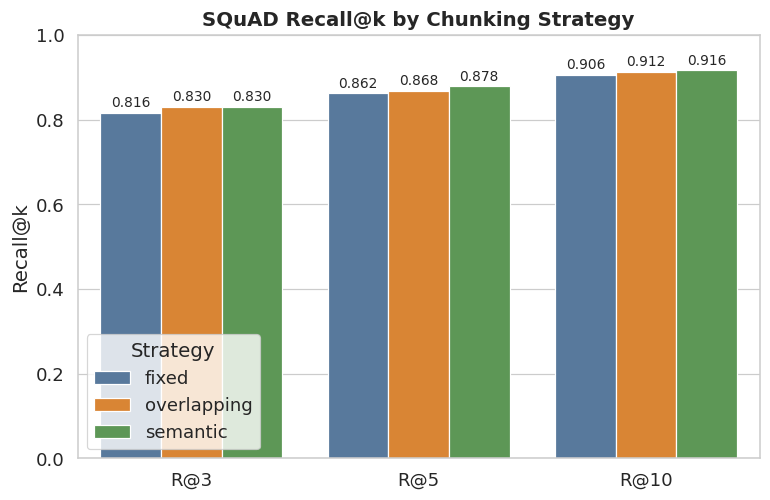

saved: res_squad_recall


In [ ]:
sr = load('phase1/squad_recall.json')
rows = [(strat, f'R@{k}', sr[strat][str(k)]) for strat in ['fixed','overlapping','semantic'] for k in [3,5,10]]
df = pd.DataFrame(rows, columns=['strategy', 'k', 'recall'])
plt.figure()
ax = sns.barplot(df, x='k', y='recall', hue='strategy',
                 palette={k: STRAT_COLORS[k] for k in ['fixed','overlapping','semantic']})
annotate(ax)
plt.title('SQuAD Recall@k by Chunking Strategy'); plt.ylim(0, 1)
plt.xlabel(''); plt.ylabel('Recall@k'); plt.legend(title='Strategy')
save_fig('res_squad_recall')


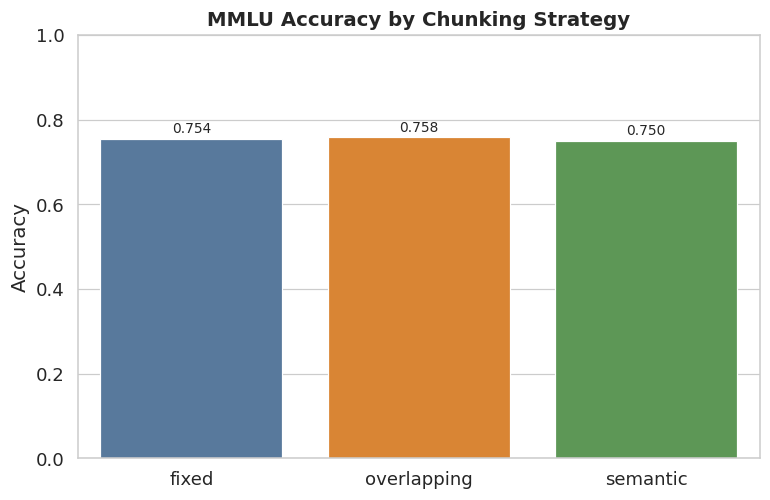

saved: res_mmlu_accuracy


In [ ]:
ma = load('phase1/mmlu_accuracy.json')
df = pd.DataFrame({'strategy': list(ma.keys()), 'accuracy': list(ma.values())})
plt.figure()
ax = sns.barplot(df, x='strategy', y='accuracy', hue='strategy',
                 palette={k: STRAT_COLORS[k] for k in ma}, legend=False)
annotate(ax)
plt.title('MMLU Accuracy by Chunking Strategy'); plt.ylim(0, 1)
plt.xlabel(''); plt.ylabel('Accuracy')
save_fig('res_mmlu_accuracy')


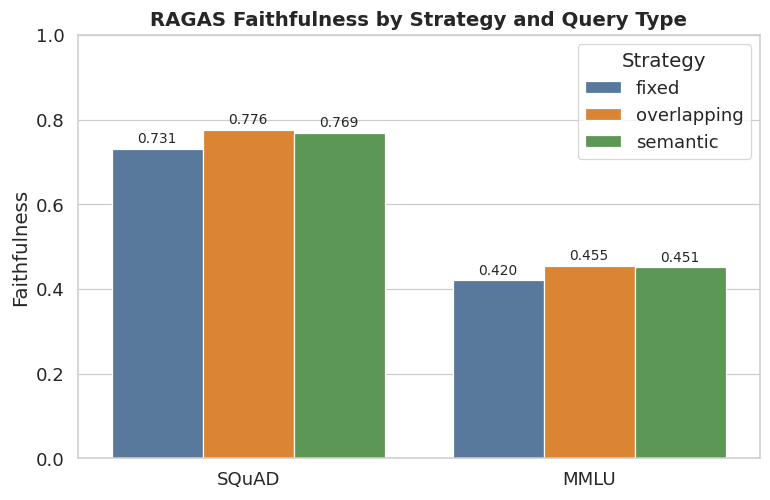

saved: res_ragas_faithfulness


In [ ]:
rows = []
for strat in ['fixed','overlapping','semantic']:
    t = TAG[strat]
    rows.append(('SQuAD', strat, load(f'phase1/ragas_squad_{t}.json')['faithfulness']))
    rows.append(('MMLU',  strat, load(f'phase1/ragas_mmlu_{t}.json')['faithfulness']))
df = pd.DataFrame(rows, columns=['corpus', 'strategy', 'faithfulness'])
plt.figure()
ax = sns.barplot(df, x='corpus', y='faithfulness', hue='strategy',
                 palette={k: STRAT_COLORS[k] for k in ['fixed','overlapping','semantic']})
annotate(ax)
plt.title('RAGAS Faithfulness by Strategy and Query Type'); plt.ylim(0, 1)
plt.xlabel(''); plt.ylabel('Faithfulness'); plt.legend(title='Strategy')
save_fig('res_ragas_faithfulness')


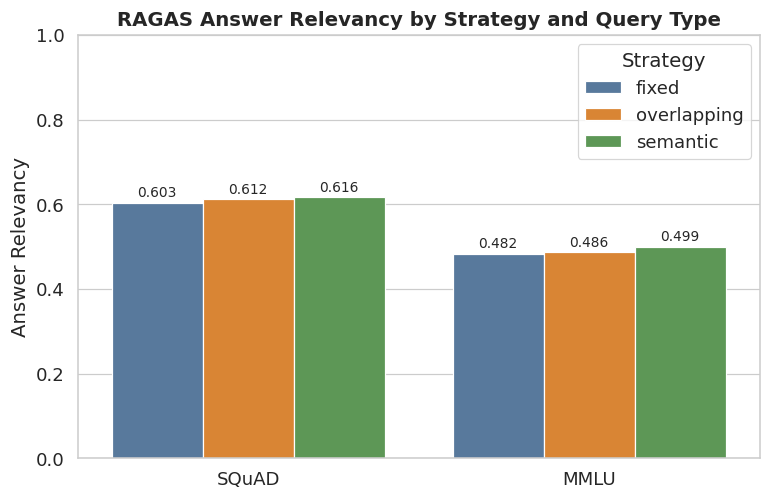

saved: res_ragas_answer_relevancy


In [ ]:
rows = []
for strat in ['fixed','overlapping','semantic']:
    t = TAG[strat]
    rows.append(('SQuAD', strat, load(f'phase1/ragas_squad_{t}.json')['answer_relevancy']))
    rows.append(('MMLU',  strat, load(f'phase1/ragas_mmlu_{t}.json')['answer_relevancy']))
df = pd.DataFrame(rows, columns=['corpus', 'strategy', 'answer_relevancy'])
plt.figure()
ax = sns.barplot(df, x='corpus', y='answer_relevancy', hue='strategy',
                 palette={k: STRAT_COLORS[k] for k in ['fixed','overlapping','semantic']})
annotate(ax)
plt.title('RAGAS Answer Relevancy by Strategy and Query Type'); plt.ylim(0, 1)
plt.xlabel(''); plt.ylabel('Answer Relevancy'); plt.legend(title='Strategy')
save_fig('res_ragas_answer_relevancy')


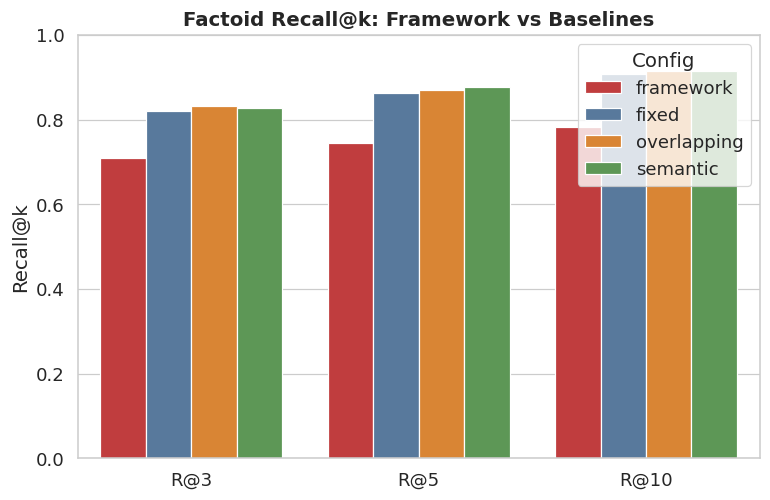

saved: res_framework_recall


In [ ]:
ret = load('phase2/framework_vs_baselines_retrieval.json')['recall_factoid']
order = ['framework','fixed','overlapping','semantic']
rows = [(c, f'R@{k}', ret[c][str(k)]) for c in order for k in [3,5,10]]
df = pd.DataFrame(rows, columns=['config', 'k', 'recall'])
plt.figure()
ax = sns.barplot(df, x='k', y='recall', hue='config', hue_order=order,
                 palette={c: STRAT_COLORS[c] for c in order})
plt.title('Factoid Recall@k: Framework vs Baselines'); plt.ylim(0, 1)
plt.xlabel(''); plt.ylabel('Recall@k'); plt.legend(title='Config')
save_fig('res_framework_recall')


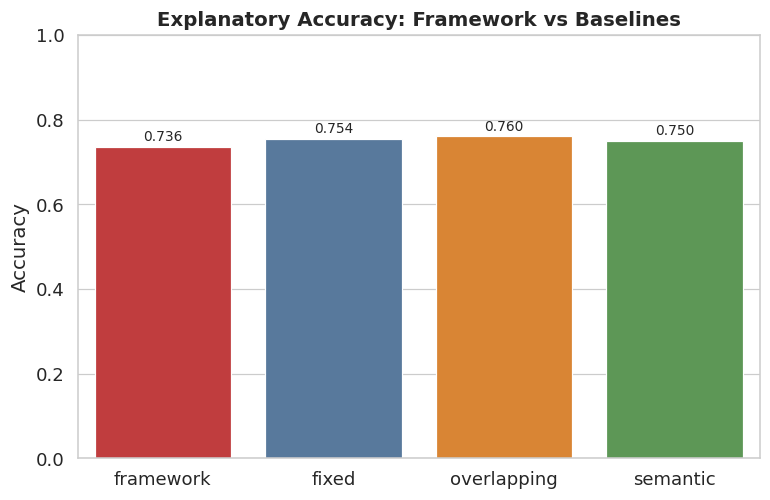

saved: res_framework_accuracy


In [ ]:
acc = load('phase2/framework_vs_baselines_retrieval.json')['accuracy_explanatory']
order = ['framework','fixed','overlapping','semantic']
df = pd.DataFrame({'config': order, 'accuracy': [acc[c] for c in order]})
plt.figure()
ax = sns.barplot(df, x='config', y='accuracy', hue='config',
                 palette={c: STRAT_COLORS[c] for c in order}, legend=False)
annotate(ax)
plt.title('Explanatory Accuracy: Framework vs Baselines'); plt.ylim(0, 1)
plt.xlabel(''); plt.ylabel('Accuracy')
save_fig('res_framework_accuracy')


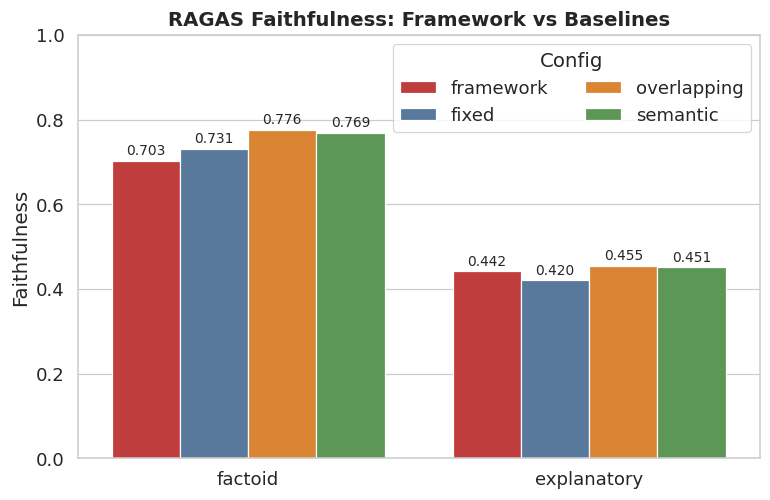

saved: res_framework_faithfulness


In [ ]:
fw_f = load('phase2/ragas_framework_factoid.json')['faithfulness']
fw_e = load('phase2/ragas_framework_explanatory.json')['faithfulness']
rows = [('factoid','framework',fw_f), ('explanatory','framework',fw_e)]
for strat in ['fixed','overlapping','semantic']:
    t = TAG[strat]
    rows.append(('factoid', strat, load(f'phase1/ragas_squad_{t}.json')['faithfulness']))
    rows.append(('explanatory', strat, load(f'phase1/ragas_mmlu_{t}.json')['faithfulness']))
df = pd.DataFrame(rows, columns=['arm', 'config', 'faithfulness'])
order = ['framework','fixed','overlapping','semantic']
plt.figure()
ax = sns.barplot(df, x='arm', y='faithfulness', hue='config', hue_order=order,
                 palette={c: STRAT_COLORS[c] for c in order})
annotate(ax)
plt.title('RAGAS Faithfulness: Framework vs Baselines'); plt.ylim(0, 1)
plt.xlabel(''); plt.ylabel('Faithfulness'); plt.legend(title='Config', ncol=2)
save_fig('res_framework_faithfulness')


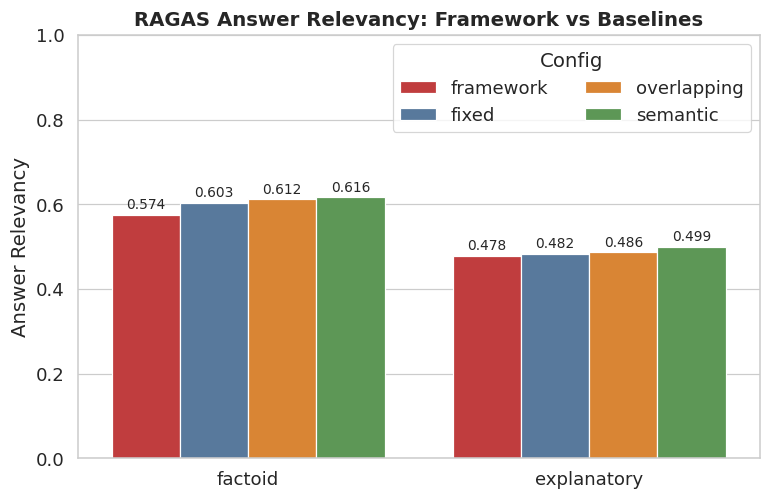

saved: res_framework_answer_relevancy


In [ ]:
fw_f = load('phase2/ragas_framework_factoid.json')['answer_relevancy']
fw_e = load('phase2/ragas_framework_explanatory.json')['answer_relevancy']
rows = [('factoid','framework',fw_f), ('explanatory','framework',fw_e)]
for strat in ['fixed','overlapping','semantic']:
    t = TAG[strat]
    rows.append(('factoid', strat, load(f'phase1/ragas_squad_{t}.json')['answer_relevancy']))
    rows.append(('explanatory', strat, load(f'phase1/ragas_mmlu_{t}.json')['answer_relevancy']))
df = pd.DataFrame(rows, columns=['arm', 'config', 'answer_relevancy'])
order = ['framework','fixed','overlapping','semantic']
plt.figure()
ax = sns.barplot(df, x='arm', y='answer_relevancy', hue='config', hue_order=order,
                 palette={c: STRAT_COLORS[c] for c in order})
annotate(ax)
plt.title('RAGAS Answer Relevancy: Framework vs Baselines'); plt.ylim(0, 1)
plt.xlabel(''); plt.ylabel('Answer Relevancy'); plt.legend(title='Config', ncol=2)
save_fig('res_framework_answer_relevancy')


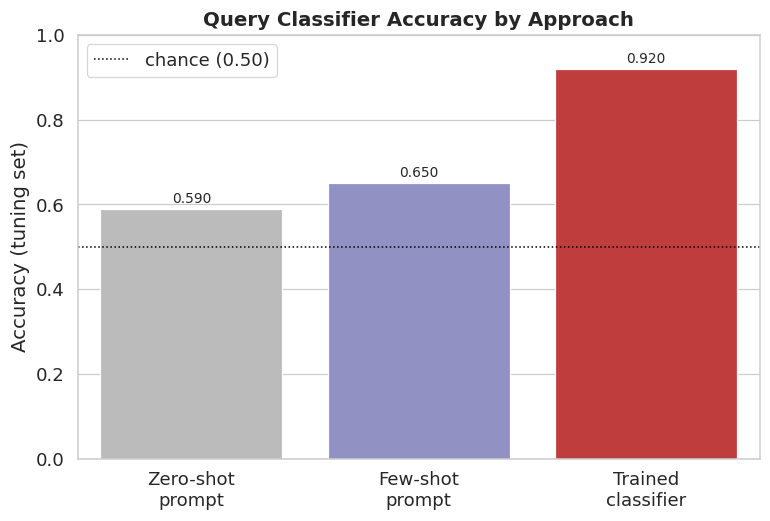

saved: res_classifier_progression


In [ ]:
stages = ['Zero-shot\nprompt', 'Few-shot\nprompt', 'Trained\nclassifier']
accs = [0.59, 0.65, 0.92]
plt.figure()
ax = sns.barplot(x=stages, y=accs, hue=stages,
                 palette=['#bbbbbb', '#8888cc', STRAT_COLORS['framework']], legend=False)
annotate(ax)
plt.axhline(0.5, color='black', ls=':', lw=1, label='chance (0.50)')
plt.title('Query Classifier Accuracy by Approach'); plt.ylim(0, 1)
plt.xlabel(''); plt.ylabel('Accuracy (tuning set)'); plt.legend()
save_fig('res_classifier_progression')


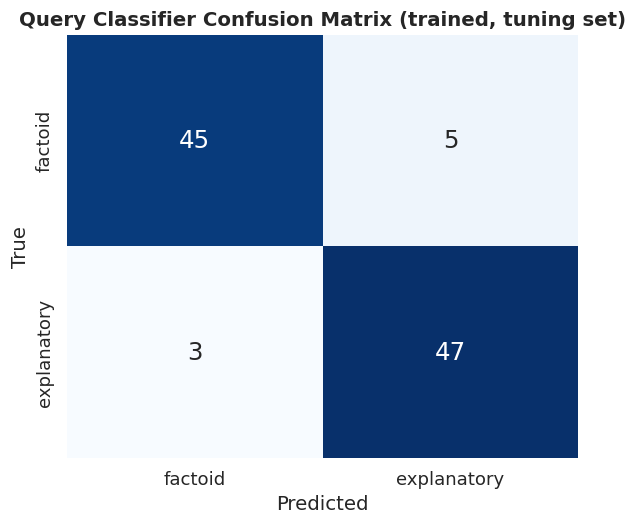

saved: res_classifier_confusion


In [ ]:
cm = np.array([[45, 5], [3, 47]])
labels = ['factoid', 'explanatory']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels, annot_kws={'size': 16})
plt.title('Query Classifier Confusion Matrix (trained, tuning set)')
plt.xlabel('Predicted'); plt.ylabel('True')
save_fig('res_classifier_confusion')


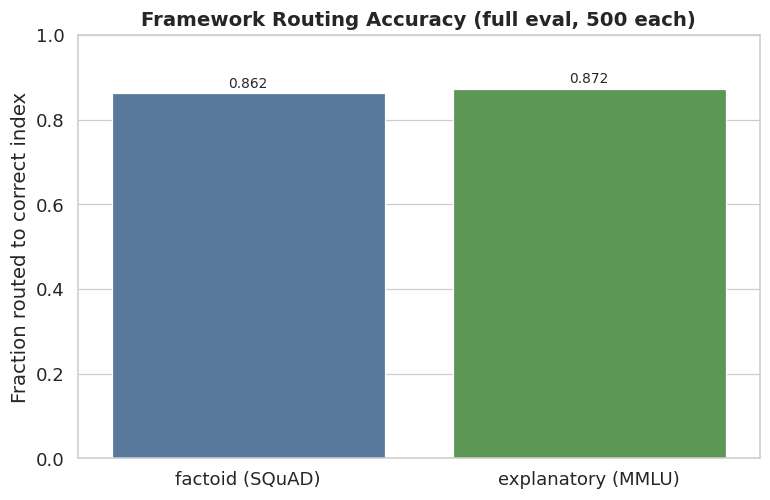

saved: res_routing_accuracy


In [ ]:
df = pd.DataFrame({'arm': ['factoid (SQuAD)', 'explanatory (MMLU)'], 'routed_correctly': [0.862, 0.872]})
plt.figure()
ax = sns.barplot(df, x='arm', y='routed_correctly', hue='arm',
                 palette=[STRAT_COLORS['fixed'], STRAT_COLORS['semantic']], legend=False)
annotate(ax)
plt.title('Framework Routing Accuracy (full eval, 500 each)'); plt.ylim(0, 1)
plt.xlabel(''); plt.ylabel('Fraction routed to correct index')
save_fig('res_routing_accuracy')


In [ ]:
def rag(split, strat): return load(f'phase1/ragas_{split}_{TAG[strat]}.json')
sr = load('phase1/squad_recall.json'); ma = load('phase1/mmlu_accuracy.json')

rows = []
for strat in ['fixed','overlapping','semantic']:
    rows.append({'config': strat,
        'SQuAD R@3': sr[strat]['3'], 'SQuAD R@10': sr[strat]['10'],
        'MMLU acc': ma[strat],
        'SQuAD faith': rag('squad',strat)['faithfulness'], 'MMLU faith': rag('mmlu',strat)['faithfulness'],
        'SQuAD rel': rag('squad',strat)['answer_relevancy'], 'MMLU rel': rag('mmlu',strat)['answer_relevancy']})
ret = load('phase2/framework_vs_baselines_retrieval.json')
rows.append({'config': 'framework',
    'SQuAD R@3': ret['recall_factoid']['framework']['3'], 'SQuAD R@10': ret['recall_factoid']['framework']['10'],
    'MMLU acc': ret['accuracy_explanatory']['framework'],
    'SQuAD faith': load('phase2/ragas_framework_factoid.json')['faithfulness'],
    'MMLU faith': load('phase2/ragas_framework_explanatory.json')['faithfulness'],
    'SQuAD rel': load('phase2/ragas_framework_factoid.json')['answer_relevancy'],
    'MMLU rel': load('phase2/ragas_framework_explanatory.json')['answer_relevancy']})

table = pd.DataFrame(rows).round(3)
table.to_csv(f'{FIG_DIR}/results_master_table.csv', index=False)
print('saved results_master_table.csv\n')
print(table.to_string(index=False))


saved results_master_table.csv

     config  SQuAD R@3  SQuAD R@10  MMLU acc  SQuAD faith  MMLU faith  SQuAD rel  MMLU rel
      fixed      0.816       0.906     0.754        0.731       0.420      0.603     0.482
overlapping      0.830       0.912     0.758        0.776       0.455      0.612     0.486
   semantic      0.830       0.916     0.750        0.769       0.451      0.616     0.499
  framework      0.710       0.782     0.736        0.703       0.442      0.574     0.478


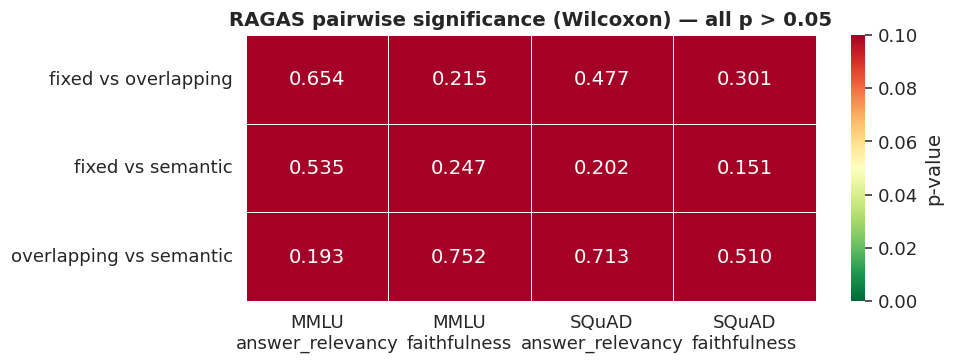

saved res_significance_heatmap.png


In [ ]:
import json
sig = json.load(open(f'{PROJECT_ROOT}/results/phase1/ragas_significance.json'))
recs = []
for k, p in sig.items():
    ds = 'SQuAD' if k.startswith('squad') else 'MMLU'
    metric = 'faithfulness' if 'faithfulness' in k else 'answer_relevancy'
    pair = k.replace('squad_', '').replace('mmlu_', '') \
            .replace(f'{metric}_', '').replace('_vs_', ' vs ')
    recs.append({'pair': pair, 'col': f'{ds}\n{metric}', 'p': p})
df = pd.DataFrame(recs).pivot(index='pair', columns='col', values='p')

plt.figure(figsize=(9, 3.5))
sns.heatmap(df, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=0.1,
            cbar_kws={'label': 'p-value'}, linewidths=0.6)
plt.title('RAGAS pairwise significance (Wilcoxon) — all p > 0.05')
plt.ylabel(''); plt.xlabel('')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/res_significance_heatmap.png'); plt.show()
print('saved res_significance_heatmap.png')